# NB04: Iteration

## Programming Fundamentals 

## L.EIC/2025-26

#### Coordinator: Alexandra Mendes, FEUP/DEI and INESC TEC

> “Programming is the art of telling another human being what one wants the computer to do.”

Donald Knuth

## Goals

By the end of this class, the student should be able to:

- Describe how to do iterations using `while` statements
- Describe *middle-test* and *post-test* loops using the `break` and `continue` statements
- Choose between `for` and `while` loops
- Use nested loops for nested data (for example list of pairs)


## Bibliography

- Peter Wentworth, Jeffrey Elkner, Allen B. Downey, and Chris Meyers, *How to Think Like a Computer Scientist — Learning with Python 3* (Section 3.3) [[PDF](https://media.readthedocs.org/pdf/howtothink/latest/howtothink.pdf)]
[[HTML](http://openbookproject.net/thinkcs/python/english3e/)]

- Brad Miller and David Ranum, *Learning with Python: Interactive Edition*. Based on material by Jeffrey Elkner, Allen B. Downey, and Chris Meyers (Chapter 8) [[HTML](https://runestone.academy/ns/books/published/thinkcspy/index.html)]

# 4 Iteration

### Iteration in more detail

- Computers are often used to automate repetitive tasks.

- Repeating identical or similar tasks without making errors is something that computers do well and people do poorly.

- Repeated execution of a set of statements is called **iteration**.

- Python provides several language features to make it easier:
    - We've already seen the `for` statement;
    - We're going to look at the `while` statement.

- Before we do that, let's just review a few ideas ...

## 4.1 Assignment

**Assignment revisited**

- It is legal to make more than one assignment to the same variable.

- A new assignment makes an existing variable refer to a new value.

- Because Python uses the equal token (`=`) for assignment, it is tempting to interpret a statement like `a = b` as a Boolean test. **Unlike mathematics, it is not!**

- Remember that the Python (and most programming languages) token for the equality operator is `==`.

$\Rightarrow$
<https://github.com/asfmendes/FPRo-public/blob/master/lectures/04/assignment.py>

See the Runestone Interactive video:

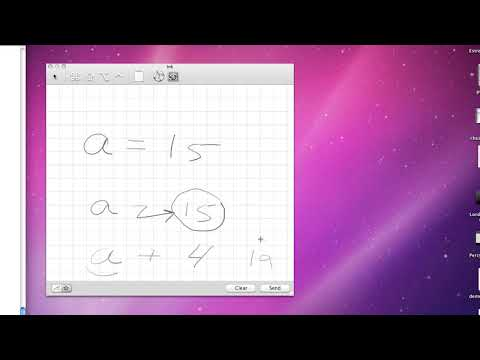

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('G86akhNFHZA')

## 4.2 Updating variables


**Updating variables revisited**

- When an assignment statement is executed, the right-hand side expression (i.e. the *expression* that comes after the assignment token) is evaluated first.

- This produces a *value*.

- Then the assignment is made, so that the variable (assignable) on the left-hand side now *refers to* the new value.




- Before you can update a variable, you have to **initialize** it to some starting value, usually with a simple assignment.

- Updating a variable by adding 1 to it, is called an **increment**.

- Subtracting 1 is called a **decrement**.

$\Rightarrow$
<https://github.com/asfmendes/FPRo-public/blob/master/lectures/04/assignment.py>

Runestone Interactive video:

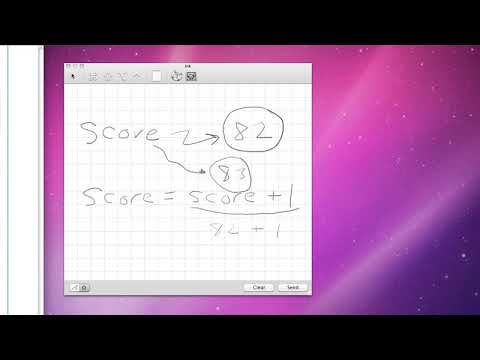

In [2]:
from IPython.display import YouTubeVideo
YouTubeVideo('Px1c-3GP-5o')

## 4.4 The `while` loop

- `while` loops repeat while a certain *condition* evaluates to true.

- The condition can be any Boolean expression (just like in `if` statements).

### Flow of execution of the `while` loop

```python
while <condition>:
   <statements>
```

![while](https://raw.githubusercontent.com/asfmendes/FPRo-public/main/notebooks/04/while2.png)

$\Rightarrow$ [thinkcspy interactive](https://runestone.academy/runestone/books/published/thinkcspy/MoreAboutIteration/toctree.html)

**Accumulated sum**

Let's try a `while` cycle.

In [ ]:
n = 6            # the last number
current_sum = 0  # the accumulator
i = 0            # cycle variable

In [5]:
while i <= n:    # iteration
   current_sum += i
   i += 1

In [ ]:
print(current_sum)

### Infinite loops

- The body of the loop should change the value of one or more variables so that *eventually*<sup>1</sup> the condition becomes false and the loop terminates.

- Otherwise the loop will repeat forever, which is called an **infinite loop**.

<sup>1</sup> We use the adverb eventually to mean "in the end", especially when something has involved a long time, or a lot of effort or problems ([Cambridge dictionary](https://dictionary.cambridge.org))


### Choosing between `for` and `while` loops

- **Definite iteration** --- we know ahead of time some definite bounds for what is needed.

    - Use a `for` loop if you know, before you start looping, the maximum number of times that you'll need to execute the body.

    - Examples: "iterate this weather model for 1000 cycles", or "search this list of words", "find all prime numbers up to 10000".



- **Indefinite iteration** --- we're not sure how many iterations we'll need, we cannot even establish an upper bound!

    - If you are required to repeat some computation until some condition is met, and you cannot calculate in advance when (or if) this will happen, you'll need a `while` loop

    - Example: "iterate this weather model until it stabilizes".

### Randomly walking turtles

Suppose we want to entertain ourselves by watching a turtle wander around randomly inside the screen. When we run the program we want the turtle and program to behave in the following way:

1. The turtle begins in the center of the screen.

1. Flip a coin. If it’s *heads* then turn to the left 90 degrees. If it’s *tails* then turn to the right 90 degrees.

1. Take 50 steps forward.

1. If the turtle has moved outside the screen then stop, otherwise go back to step 2 and repeat.

$\Rightarrow$
[thinkcspy interactive](https://runestone.academy/runestone/books/published/thinkcspy/MoreAboutIteration/RandomlyWalkingTurtles.html)

**Pseudo-code**

So based on the problem description above, we can outline a program as follows:


```
create a window and a turtle

while the turtle is still in the window:
    generate a random integer that is either 0 and 1
    if the number == 0 (heads):
        turn left
    else:
        turn right
    move the turtle forward 50
```

Let's do a first version without testing the boundaries of the window.

In [ ]:
!pip3 install ColabTurtle

In [ ]:
import random
import ColabTurtle.Turtle as tess

tess.initializeTurtle()
tess.bgcolor("green")
tess.shape('turtle')

while random.random() > 0.1:       # random finish
    coin = random.randrange(0, 2)  # throw the coin
    if coin == 0:        # heads
        tess.left(90)
    else:                # tails
        tess.right(90)
    tess.forward(50)

**Random walk complete code**

Get the code from here:.

$\Rightarrow$
<https://github.com/asfmendes/FPRo-public/blob/master/lectures/04/random_walk.py>

## 4.5 The Collatz 3n + 1 sequence

For another example of indefinite iteration, let’s look at a sequence that has fascinated mathematicians for many years:

**Collatz conjecture**

> “All positive integers will eventually converge to 1 using the Collatz rules”

**Computational rule**:

> The rule for creating the sequence is to **start** from some given *n*,\
and to generate the **next term** of the sequence from *n*,\
either by halving *n* (whenever *n* is even),\
or else by multiplying it by 3 and adding 1.\
The sequence **terminates** when *n* reaches 1.

In [1]:
n = 1027371
while n != 1:
    print(n, end=", ")
    if n % 2 == 0:
        n = n // 2
    else:
        n = n * 3 + 1
print(n, end=".\n")

1027371, 3082114, 1541057, 4623172, 2311586, 1155793, 3467380, 1733690, 866845, 2600536, 1300268, 650134, 325067, 975202, 487601, 1462804, 731402, 365701, 1097104, 548552, 274276, 137138, 68569, 205708, 102854, 51427, 154282, 77141, 231424, 115712, 57856, 28928, 14464, 7232, 3616, 1808, 904, 452, 226, 113, 340, 170, 85, 256, 128, 64, 32, 16, 8, 4, 2, 1.


## 4.6 Relationship between `for` and `while`

* It is always possible to rewrite a `for` loop as a `while` loop.
* But the reverse is not true.
* For example: it is not possible to write the Collatz computation as a `for` loop because we don't know how many times to run the loop.



In [2]:
for i in range(5):
    print(i, end = " ")

0 1 2 3 4 

In [3]:
i = 0
while i<5:
    print(i, end = " ")
    i = i + 1

0 1 2 3 4 

## 4.7 Counting digits

The following snippet *counts* the number of decimal digits in a positive integer.

In [4]:
n = int(input("Give me a number? "))
count = 0
while n != 0:
    count = count + 1
    n = n // 10
print(count)

4


This snippet demonstrates an important pattern of computation called a **counter**.

See more on:

$\Rightarrow$
<https://github.com/asfmendes/FPRo-public/blob/master/lectures/04/counter.py>

## 4.8 Tables

- One of the things loops are good for is generating tables.

- Let's create a program that outputs a sequence of values in the left column and 2 raised to the power of that value in the right column

    - using the "tab separator" *escape sequence*.

In [ ]:
print("n", "\t", "2**n")     # table column headings
print("---", "\t", "-----")

for x in range(11):          # generate values for columns
    print(x, "\t", 2 ** x)

## 4.9 Two-dimensional tables

- A two-dimensional table is a table where you read the value at the intersection of a row and a column.

- Let's say you want to print a multiplication table for the values from 1 to 10.

- A good way *to start* is to write a loop that prints the multiples of 2 in a single line:

    - we can change the character `print()` puts at the end of the string through an *optional* argument (more on this later);
    - argument `end="\t"` specifies a *tabulation* character than a newline.

In [5]:
print("One line:")
for i in range(1, 11):
    print(2 * i, end="\t")
print()
print("\nto be continued...")

One line:
2	4	6	8	10	12	14	16	18	20	

to be continued...


- Now we can put a `for` loop around this program to print 10 lines instead of just one.

- This is called a *nested loop*.

- The inner loop restarts for every iteration of the outer loop.

In [6]:
for j in range(1, 11):        # loop over lines
    for i in range(1, 11):    # loop over columns
        print(i*j, end="\t")  # print each entry
    print()                   # end each line

1	2	3	4	5	6	7	8	9	10	
2	4	6	8	10	12	14	16	18	20	
3	6	9	12	15	18	21	24	27	30	
4	8	12	16	20	24	28	32	36	40	
5	10	15	20	25	30	35	40	45	50	
6	12	18	24	30	36	42	48	54	60	
7	14	21	28	35	42	49	56	63	70	
8	16	24	32	40	48	56	64	72	80	
9	18	27	36	45	54	63	72	81	90	
10	20	30	40	50	60	70	80	90	100	


## 4.10 The `break` statement

- The **break** statement is used to *immediately leave the body of the closest loop*.

- The next statement to be executed is the first one after the loop body.

In [7]:
for i in [12, 16, 17, 24, 29]:
    if i % 2 == 1:    # if the number is odd ...
        break         # ... immediately exit the loop
    print(i)
print("done.")

12
16
done.


## 4.11 Other flavours of loops

- `for` and `while` loops do their tests at the start: they're called **pre-test loops**.

- Sometimes it's useful to have a **middle-test loop** with the exit test in the middle of the body.

- Or a **post-test loop** that has its exit test as the last thing in the body.

- Python does not have that kind of these statements, but they can be achieved with `break` statements.

### Middle-exit loop

![break](https://raw.githubusercontent.com/asfmendes/FPRo-public/main/notebooks/04/break.png)

In [2]:
total = 0
while True:
    response = input("Enter the next number. (Leave blank to end)")
    if response == "" or response == "-1":
        break
    total += int(response)
print("The total of the numbers you entered is", total)

The total of the numbers you entered is 6


### Post-test loop


```python
while True:
   play_the_game_once()
   response = input("Play again? (yes or no)")
   if response != "yes":
      break
print("Goodbye!")
```

$\Rightarrow$
<https://github.com/asfmendes/FPRo-public/blob/master/lectures/04/break.py>

## 4.12 A simple guessing game

- The *guessing game* program makes use of the mathematical law of **trichotomy**.

- Given real numbers `a` and `b`, exactly one of these three must be true:

    - `a > b`, `a < b`, or `a == b`.

In [3]:
import random                      # we cover random numbers in the modules chapter
number = random.randrange(1, 1000) # get a random number between (1 and 1000).

guesses = 0     # the "counter" with the number of guesses
message = ""    # the "accumulated" message

while True:
  guess = int(input(message + "\nGuess my number between 1 and 1000: "))
  guesses += 1  # one more guess
  if guess > number:
    pass   # TODO: add a line to the message
  elif guess < number:
    pass   # TODO: add a line to the message
  else:
    pass   # TODO: leave the cycle immediately

print("\nGreat, you got it in " + str(guesses) + " guesses!\n")

ValueError: invalid literal for int() with base 10: ''

$\Rightarrow$
<https://github.com/asfmendes/FPRo-public/blob/master/lectures/04/guess.py>

Note, however, that the `while True`can be avoided by replacing it with an expression that reflects under which conditions the loop should continue to execute -- in this case, when the guess and the number are differente.


## 4.13 The `continue` statement

- This is a control flow statement that causes the program to immediately skip the rest of the body of the closest loop, *for the current iteration*.

- But the loop still carries on running for its remaining iterations.

In [ ]:
for i in [12, 16, 17, 24, 29, 30]:
    if i % 2 != 0:   # if the number is odd ... 
        continue
    print(i)

### Nested loops and `break`/`continue`

- `break` and `continue` statements only affect the loop directly above.

- Any outer loops continue to iterate normally.

In [ ]:
for j in range(0,10):
    print(j,end='\t')
    for i in range(0,100):
        if i % 2 == 0:     # skip the inner print when even
            continue
        if i > 10:
            break          # break the inner loop when >10
        print(i,end='\t')
    print()

## 4.14 Newton’s method for finding square roots



- Loops are often used in programs that compute numerical results by starting with an approximate answer and iteratively improving it.

- For example, consider Newton's method for finding the square root of  `n`.

- Starting with almost any approximation, a better approximation can be computed (closer to the actual answer) with the following formula:

    - `better = 0.5 * (approximation + n/approximation)`

- One of the amazing properties of this particular algorithm is how quickly it converges to an accurate answer (a great advantage for doing it manually).

Let's try it:

In [9]:
n = int(input("input number n: "))

In [10]:
threshold = 0.001      # use more precision if needed
approximation = n/2    # start with some or other guess at the answer

In [11]:
while True:
    better = 0.5 * (approximation + n/approximation)
    #print(better)

    if abs(approximation - better) < threshold:
        print("approx root: ", better)
        break

    approximation = better

# Try to remove the True from the while. Think about which condition requires further executions.    

approx root:  2.6457513110646933


**The accumulator pattern**

- Newton's method to calculate square roots is an example of an algorithm that repeats as long as it can improve the result.

- This is another case where we may use an accumulator variable.

- This is a very common **pattern** in `while` loops (the *counter* pattern is a particular case):
  * initialize the accumulator variable before the loop;
  * update its value in each step of the loop;
  * retrieve its final value after the loop.

- Many algorithms work this way and so require the use of indefinite iteration.


**Another example**

- Let's see another accumulator pattern program that adds up the reciprocals of powers of two:

$$\frac{1}{2^0} + \frac{1}{2^1} + \frac{1}{2^2} + \ldots + \frac{1}{2^n}$$

- You may have studied this sequence in a math class and learned that the sum approaches but never reaches 2.0.

- That is true in theory. However, when we implement this summation in a program, we see something different.

In [12]:
the_sum  = 0
a_number = 0

while the_sum < 2.0:
    the_sum = the_sum + 1/2**a_number
    a_number = a_number + 1

print(a_number)
print(the_sum)

54
2.0


**Modify the program...**

- If the sum never reaches 2.0, the loop would never terminate.

- But the loop does stop!

- How many repetitions did it make before it stopped?

- On line 8 (not indented), print the value of `a_number` and you will see.

- But why did it reach 2.0? Are those math teachers wrong?

## 4.15 Algorithms

- Newton's method is an example of an **algorithm**:

    - It is a mechanical process for solving a category of problems (in this case, computing square roots).

- Some kinds of knowledge are not algorithmic:

    - Learning dates from history or multiplication tables involves memorization of specific solutions.

- But the techniques for addition with carrying, subtraction with borrowing, and long division are all algorithms.

- One of the characteristics of algorithms is that they do not require any intelligence to carry out.

    - They are mechanical processes in which each step follows from the last according to a simple set of rules.

- And they're designed to solve a general class or category of problems, not just a single problem.

### Computational thinking revisited

> Using algorithms and automation as the basis
for approaching problems is rapidly transforming our society.

- Understanding that hard problems can be solved by step-by-step algorithmic processes (and having technology to execute these algorithms for us) is one of the major breakthroughs that has had enormous benefits.

- But, some of the things that people do naturally, without difficulty or conscious thought, are the hardest to express algorithmically (e.g. Natural Llanguage Processing).

### UNCRACKABLE? The Collatz Conjecture

Numberphile

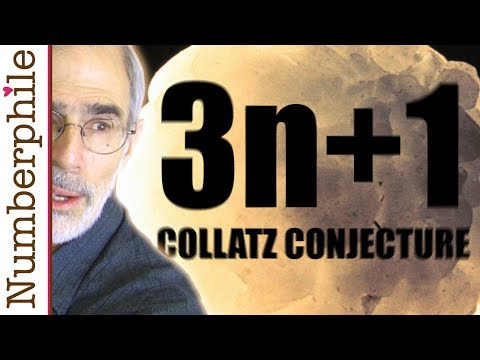

In [16]:
from IPython.display import YouTubeVideo
YouTubeVideo('5mFpVDpKX70')

## Credits
These materials have been shaped by the contributions of several people over the years. Each year, the course coordinator reviews and updates the content to ensure its quality and relevance. Below is a list of contributors who have helped improve these slides and notebooks.
- Alexandra Mendes, 2025
- João Correia Lopes, Nuno Macedo, and Alexandra Mendes (2024)
- João Correia Lopes, Pedro Vasconcelos, Nuno Macedo (2023)
- João Correia Lopes, Pedro Vasconcelos (< 2023)

-- Alexandra Mendes, Sun Sep 27 2025